In [1]:
import cv2
import matplotlib.pyplot as plt
import json
import numpy as np
import math
import os
import glob

%matplotlib inline

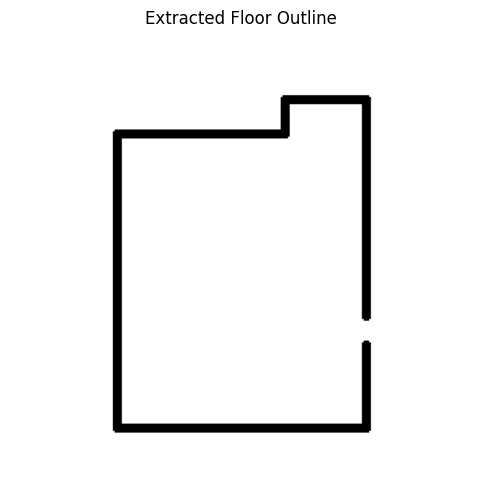

Successfully extracted 22 points.
Floor map data saved to 'floor_map.json


In [2]:
image_path = "dataset/2d floor plan/20.png"
image = cv2.imread(image_path)

if image is None:
    print(f"Error: Could not load image at {image_path}")
else:
    lower_black = np.array([0, 0, 0])
    upper_black = np.array([0, 0, 0])

    mask = cv2.inRange(image, lower_black, upper_black)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        floor_contour = max(contours, key=cv2.contourArea)

        visualization_img = np.ones_like(image) * 255
        cv2.drawContours(visualization_img, [floor_contour], -1, (0, 0, 0), 2)

        plt.figure(figsize=(6, 6))
        plt.imshow(cv2.cvtColor(visualization_img, cv2.COLOR_BGR2RGB))
        plt.title("Extracted Floor Outline")
        plt.axis("off")
        plt.show()

        points = np.squeeze(floor_contour).tolist()

        json_data = json.dumps({"floor_outline": points}, indent=4)

        file_name = "floor_map.json"
        with open(file_name, "w") as f:
            f.write(json_data)

        print(f"Successfully extracted {len(points)} points.")
        print(f"Floor map data saved to '{file_name}")

    else:
        print("No black outline was found in the image")


In [3]:
def process_floor_plan(image_path, display_plot=True, line_thickness=3):
    """
    Extracts the wall centerline via skeletonization and finds door locations.
    Allows for increasing the centerline width using dilation.
    """
    image = cv2.imread(image_path)
    if image is None:
        return None, [], None

    # --- 1. CREATE MASK FOR THE WALLS ---
    lower_black = np.array([0, 0, 0])
    upper_black = np.array([50, 50, 50])
    wall_mask = cv2.inRange(image, lower_black, upper_black)

    # Ensure the mask is a single channel and of type CV_8UC1 for thinning
    wall_mask_8u1 = cv2.threshold(wall_mask, 127, 255, cv2.THRESH_BINARY)[1]

    # --- 2. SKELETONIZE THE MASK TO GET THE CENTERLINE (1-pixel wide) ---
    centerline_1px = cv2.ximgproc.thinning(wall_mask_8u1)

    # --- NEW: 3. APPLY DILATION TO INCREASE LINE THICKNESS ---
    final_centerline_img = centerline_1px
    if line_thickness > 1:
        # Create a kernel for dilation based on desired thickness
        # A thickness of N means (N-1) / 2 pixels are added to each side of the 1px line
        # So, for a desired thickness of 3, a kernel of (3,3) should work well.
        dilation_kernel_size = line_thickness  # e.g., for thickness 3, kernel 3x3
        dilation_kernel = np.ones(
            (dilation_kernel_size, dilation_kernel_size), np.uint8
        )

        # Apply dilation
        final_centerline_img = cv2.dilate(centerline_1px, dilation_kernel, iterations=1)

    # --- 4. EXTRACT CENTERLINE POINTS (if needed) ---
    # These points will now correspond to the *thickened* line
    centerline_points = np.argwhere(final_centerline_img > 0)
    centerline_points = centerline_points[:, ::-1].tolist()

    # --- 5. CREATE VISUALIZATION ---
    # Invert the centerline to be black on white for visualization
    inverted_centerline = 255 - final_centerline_img
    visualization_img = cv2.cvtColor(inverted_centerline, cv2.COLOR_GRAY2BGR)

    # --- 6. EXTRACT DOOR LOCATIONS (Same as before) ---
    lower_door_color = np.array([0, 0, 245])
    upper_door_color = np.array([0, 30, 255])
    door_mask = cv2.inRange(image, lower_door_color, upper_door_color)

    door_contours, _ = cv2.findContours(
        door_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
    )

    door_locations = []
    for contour in door_contours:
        M = cv2.moments(contour)
        if M["m00"] != 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
            door_locations.append((cX, cY))
            cv2.circle(visualization_img, (cX, cY), 8, (0, 0, 255), -1)

    # --- 7. DISPLAY AND RETURN ---
    if display_plot:
        plt.figure(figsize=(8, 8))
        plt.imshow(cv2.cvtColor(visualization_img, cv2.COLOR_BGR2RGB))
        plt.title("Wall Centerline and Doors")
        plt.axis("off")
        plt.show()

    return centerline_points, door_locations, visualization_img


def find_image_colors(image_path):
    """
    Analyzes an image to find the average color of all distinct colored shapes.
    """
    image = cv2.imread(image_path)
    if image is None:
        print(f"Could not load image: {image_path}")
        return

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Create a mask to exclude black and white areas
    _, thresh = cv2.threshold(
        gray, 240, 255, cv2.THRESH_BINARY_INV
    )  # Invert to get non-white
    black_mask = cv2.inRange(image, np.array([0, 0, 0]), np.array([50, 50, 50]))
    non_black_mask = cv2.bitwise_not(black_mask)

    # Final mask includes things that are not white AND not black
    final_mask = cv2.bitwise_and(thresh, non_black_mask)

    # Find contours of all the colored shapes
    contours, _ = cv2.findContours(
        final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    print(f"--- Analyzing colors in: {image_path} ---")
    if not contours:
        print("No distinct color blobs were found.")
        return

    for i, contour in enumerate(contours):
        # Create a mask for each individual contour
        mask = np.zeros(gray.shape, dtype="uint8")
        cv2.drawContours(mask, [contour], -1, 255, -1)

        # Calculate the average color within that contour's area
        mean_bgr = cv2.mean(image, mask=mask)

        # Format the BGR and RGB values
        b = int(mean_bgr[0])
        g = int(mean_bgr[1])
        r = int(mean_bgr[2])

        print(
            f"Shape #{i + 1}:  Average BGR = ({b}, {g}, {r})  |  RGB = ({r}, {g}, {b})"
        )


In [4]:
find_image_colors("dataset/2d floor plan/10017.png")

--- Analyzing colors in: dataset/2d floor plan/10017.png ---
Shape #1:  Average BGR = (35, 142, 107)  |  RGB = (107, 142, 35)
Shape #2:  Average BGR = (128, 128, 240)  |  RGB = (240, 128, 128)
Shape #3:  Average BGR = (0, 165, 255)  |  RGB = (255, 165, 0)
Shape #4:  Average BGR = (0, 215, 255)  |  RGB = (255, 215, 0)
Shape #5:  Average BGR = (230, 216, 173)  |  RGB = (173, 216, 230)
Shape #6:  Average BGR = (167, 228, 238)  |  RGB = (238, 228, 167)


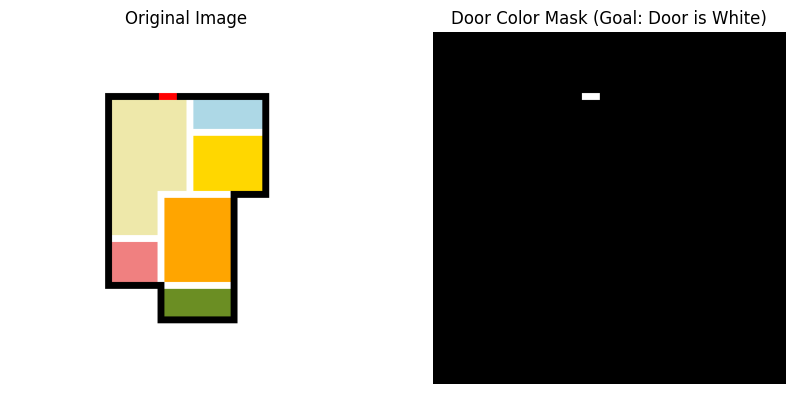

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def debug_door_color(image_path):
    """
    Use this function to find the perfect color range for your doors.
    Adjust the two arrays below until the door appears white in the right panel.
    """
    # =================== ADJUST THESE VALUES ===================
    # STARTING WITH A RANGE FOR ORANGE: BGR = (0, 165, 255)
    lower_door_color = np.array([0, 0, 245])
    upper_door_color = np.array([0, 30, 255])
    # =========================================================

    image = cv2.imread(image_path)
    if image is None:
        print(f"Could not load image: {image_path}")
        return

    # Create the mask
    door_mask = cv2.inRange(image, lower_door_color, upper_door_color)

    # Display the original and the mask side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # --- This line has been corrected ---
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(door_mask, cmap="gray")
    axes[1].set_title("Door Color Mask (Goal: Door is White)")
    axes[1].axis("off")

    plt.show()


# --- Run the debugger on an image you KNOW has a door ---
debug_door_color("dataset/2d floor plan/10017.png")

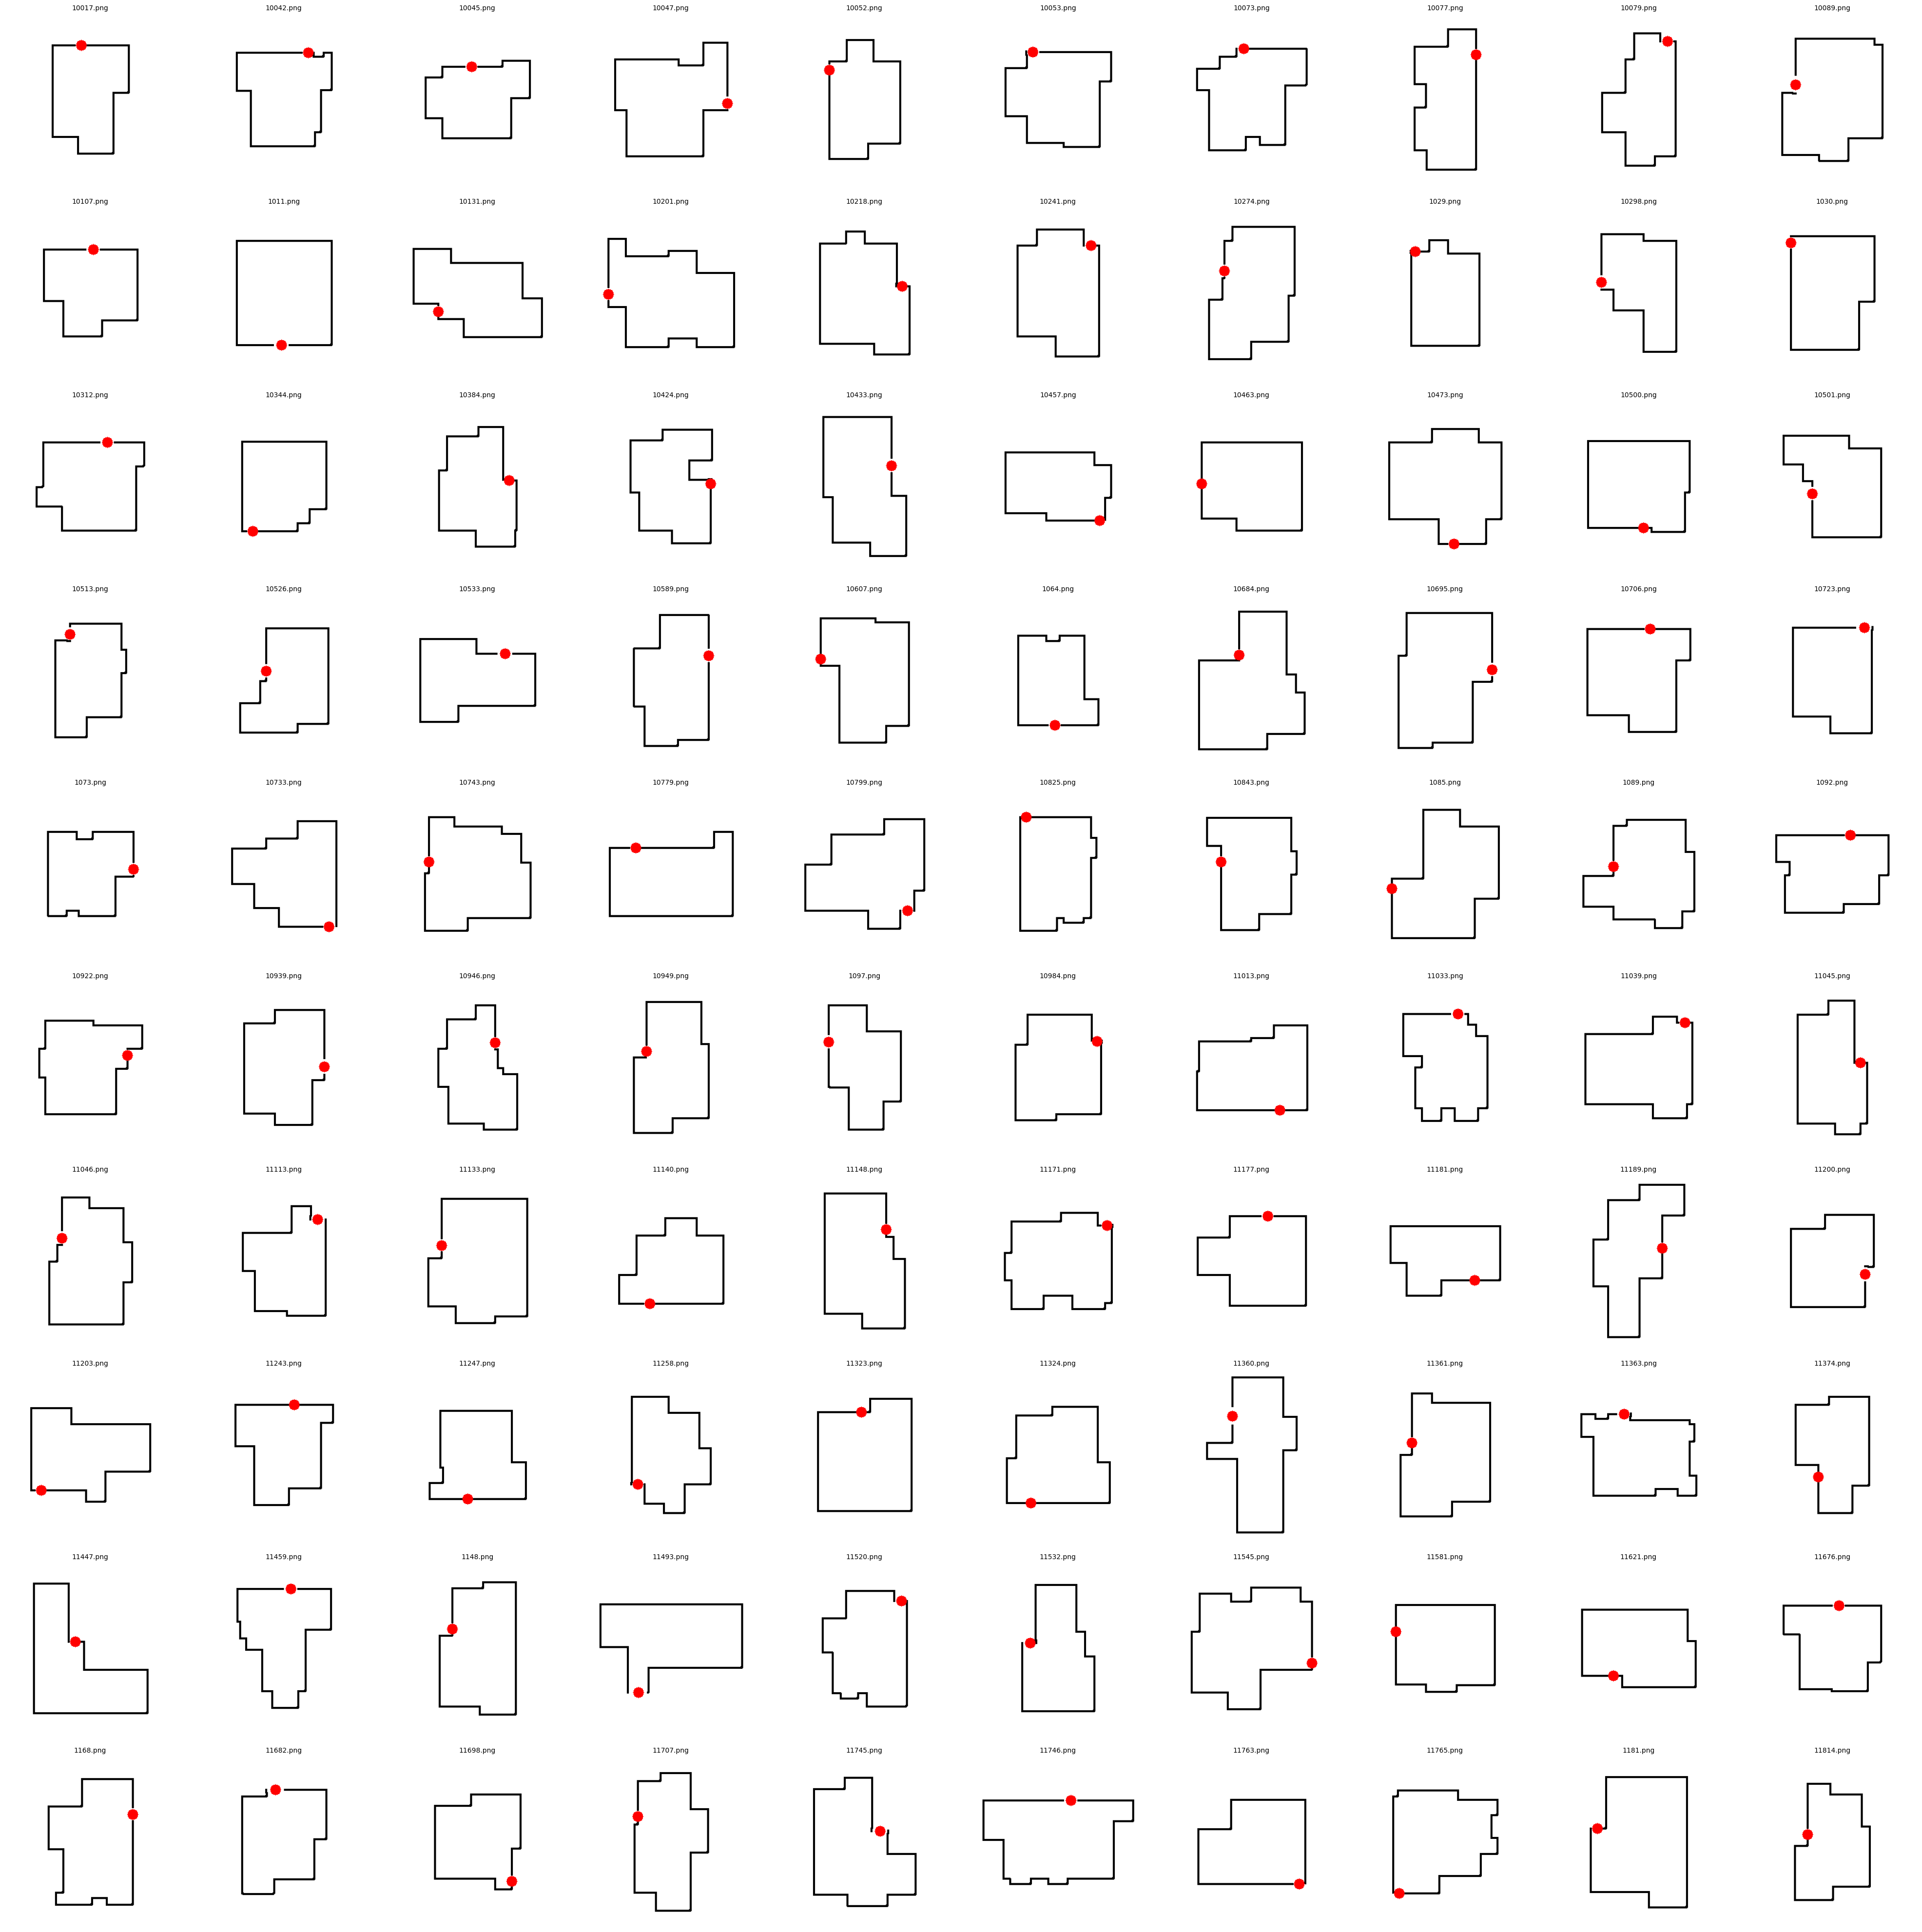

In [6]:
# --- Main Script ---
image_folder_path = "dataset/2d floor plan/*.png"
all_image_paths = glob.glob(image_folder_path)

# You can change the slice to view different images
image_paths_to_show = all_image_paths[:100]

if not image_paths_to_show:
    print(f"No PNG images found in the specified path: {image_folder_path}")
else:
    num_images = len(image_paths_to_show)
    cols = int(math.ceil(math.sqrt(num_images)))
    rows = int(math.ceil(num_images / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    for i, img_path in enumerate(image_paths_to_show):
        # --- KEY CHANGE: Unpack all three return values from the function ---
        outline_points, door_locations, vis_img = process_floor_plan(
            img_path, display_plot=False
        )

        ax = axes[i]
        ax.set_title(os.path.basename(img_path), fontsize=10)
        ax.axis("off")

        # Add a label showing how many doors were found
        if door_locations:
            ax.set_xlabel(
                f"{len(door_locations)} door(s) found", fontsize=9, color="blue"
            )

        if vis_img is not None:
            # Convert BGR (OpenCV) to RGB (Matplotlib)
            ax.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
        else:
            # Fallback for failed processing
            original_img = cv2.imread(img_path)
            if original_img is not None:
                ax.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
                ax.set_title(
                    f"{os.path.basename(img_path)}\n(Processing failed)",
                    fontsize=8,
                    color="red",
                )

    # Turn off any unused subplots
    for i in range(num_images, len(axes)):
        axes[i].axis("off")

    plt.tight_layout(pad=2.0)  # Added padding to make space for xlabel
    plt.show()